# **1. Perkenalan Dataset**


Dataset yang digunakan adalah **Resume Dataset for Job Role Classification** dari Kaggle.  
Dataset ini berisi kumpulan teks resume yang dilabeli dengan kategori pekerjaan (misalnya Data Science, HR, Software Engineer, dll).  

- **Sumber:** Kaggle (Mirza Yasir Abdullah)  
- **Jumlah kategori:** ±24 kategori pekerjaan  
- **Kolom utama:**  
  - `Category` : label pekerjaan  
  - `Resume` : teks resume  

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [6]:
# Loading raw dataset
raw_data_path = '../dataset_raw/resume_dataset.csv'
df = pd.read_csv(raw_data_path)
print("Dataset selesai di load...")
df.head()

Dataset selesai di load...


,Name,YearsExperience,Skills,Education,JobRole
0,Fatima Noor,1,"Leadership, Deep Learning, Communication, Proj...",Masters,Project Manager
1,Hassan Raza,4,"Project Management, Java, Leadership, Python",Bachelors,Data Analyst
2,Sara Ahmed,10,"Deep Learning, Data Analysis, Project Manageme...",Bachelors,Data Analyst
3,Sara Ahmed,6,"Excel, Python, Project Management, Leadership,...",PhD,Project Manager
4,Hassan Raza,10,"Data Analysis, Project Management, Deep Learni...",PhD,Data Scientist


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Name             300 non-null    object
 1   YearsExperience  300 non-null    int64 
 2   Skills           300 non-null    object
 3   Education        300 non-null    object
 4   JobRole          300 non-null    object
dtypes: int64(1), object(4)
memory usage: 11.8+ KB
None
               Name  YearsExperience  \
count           300       300.000000   
unique            8              NaN   
top     Emily Davis              NaN   
freq             49              NaN   
mean            NaN         5.763333   
std             NaN         2.898620   
min             NaN         1.000000   
25%             NaN         3.000000   
50%             NaN         6.000000   
75%             NaN         8.000000   
max             NaN        10.000000   

                                            

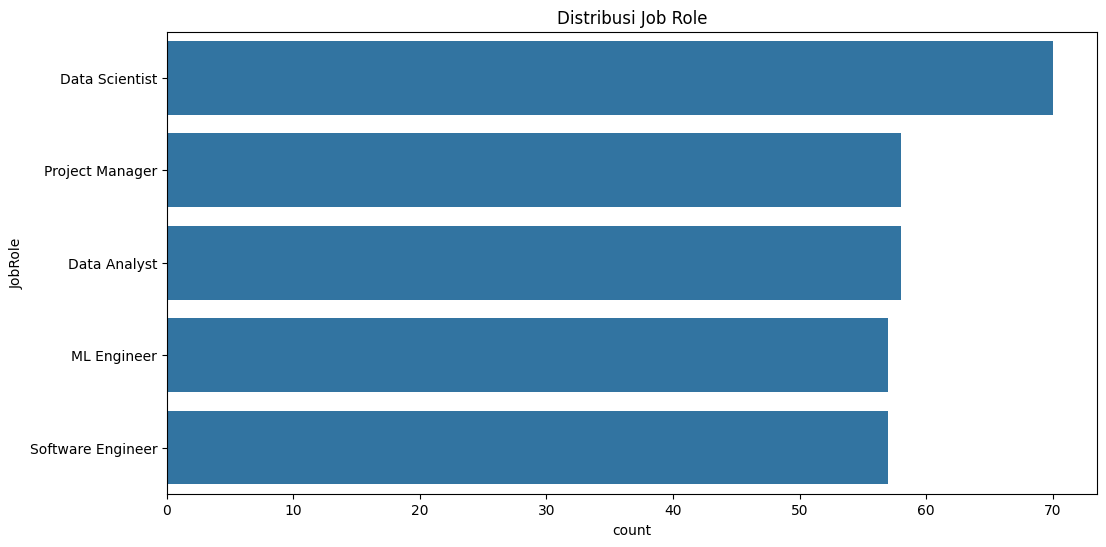

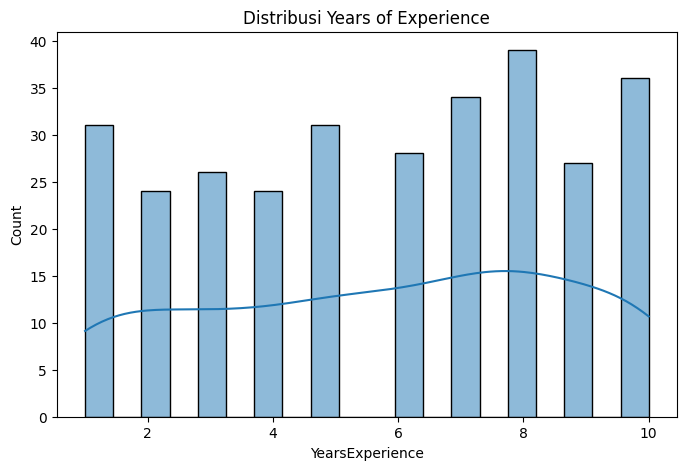

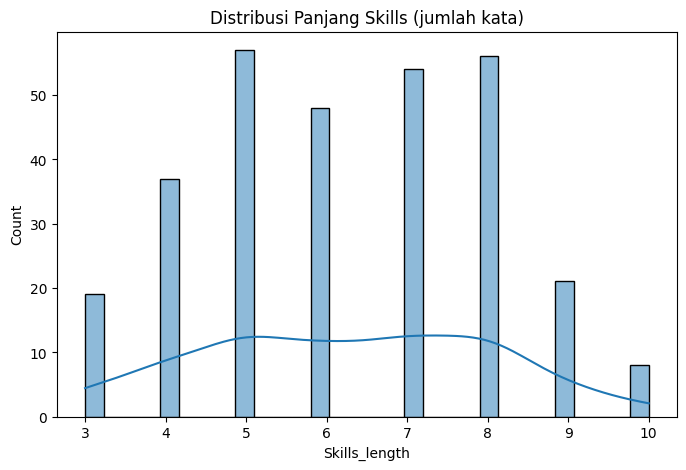

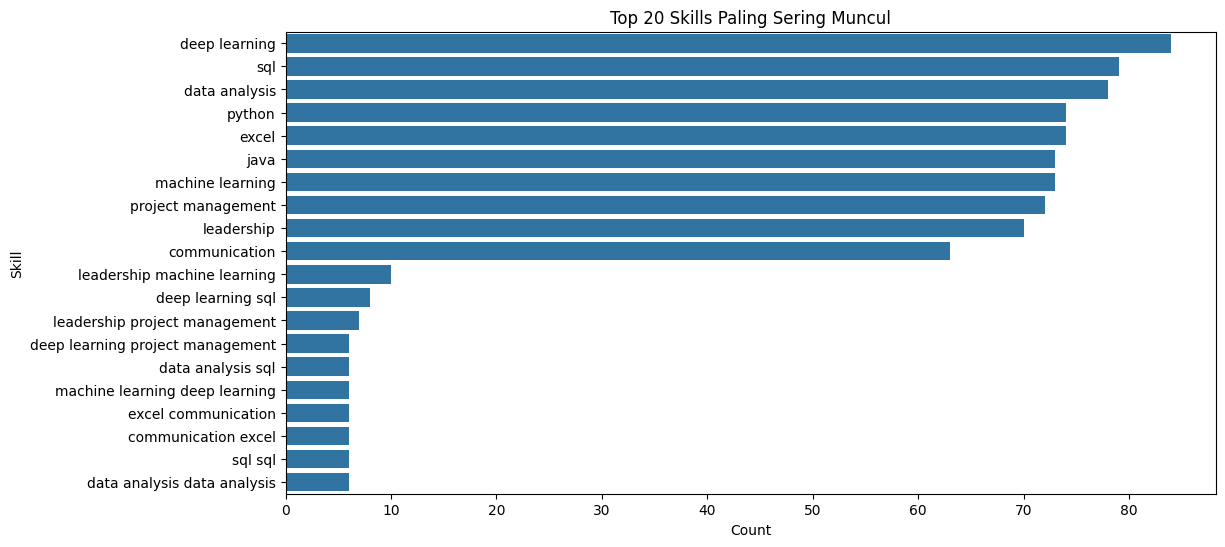

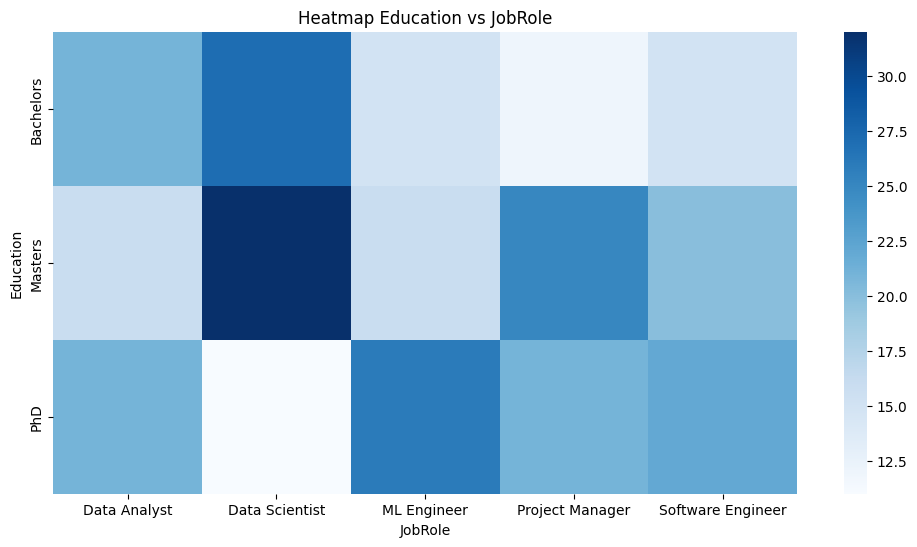

In [9]:
# 1. Info dasar
print(df.info())
print(df.describe(include='all'))

# 2. Cek missing values
print("Missing values:\n", df.isnull().sum())

# 3. Distribusi label pekerjaan
plt.figure(figsize=(12,6))
sns.countplot(y=df['JobRole'], order=df['JobRole'].value_counts().index)
plt.title("Distribusi Job Role")
plt.show()

# 4. Distribusi YearsExperience
plt.figure(figsize=(8,5))
sns.histplot(df['YearsExperience'], bins=20, kde=True)
plt.title("Distribusi Years of Experience")
plt.show()

# 5. Panjang teks Skills
df['Skills_length'] = df['Skills'].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(8,5))
sns.histplot(df['Skills_length'], bins=30, kde=True)
plt.title("Distribusi Panjang Skills (jumlah kata)")
plt.show()

# 6. Top 20 kata/skill paling sering muncul
from collections import Counter
all_skills = " ".join(df['Skills'].dropna().astype(str)).split(",")
skill_counts = Counter([s.strip().lower() for s in all_skills])
top_skills = pd.DataFrame(skill_counts.most_common(20), columns=['Skill','Count'])

plt.figure(figsize=(12,6))
sns.barplot(x='Count', y='Skill', data=top_skills)
plt.title("Top 20 Skills Paling Sering Muncul")
plt.show()

# 7. Korelasi Education vs JobRole
edu_job = pd.crosstab(df['Education'], df['JobRole'])
plt.figure(figsize=(12,6))
sns.heatmap(edu_job, cmap="Blues", annot=False)
plt.title("Heatmap Education vs JobRole")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
# 1. Drop kolom yang tidak relevan
df_clean = df.drop(columns=['Name'])

# 2. Encode JobRole
label_encoder = LabelEncoder()
df_clean['JobRole_label'] = label_encoder.fit_transform(df_clean['JobRole'])

# 3. One-hot encode Education
df_clean = pd.get_dummies(df_clean, columns=['Education'])

# 4. Scale YearsExperience
scaler = StandardScaler()
df_clean['YearsExperience_scaled'] = scaler.fit_transform(df_clean[['YearsExperience']])

# 5. TF-IDF encoding Skills
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    tokenizer=lambda x: [s.strip() for s in x.split(',')],
    lowercase=False
)
skills_tfidf = vectorizer.fit_transform(df_clean['Skills'].astype(str))
skills_df = pd.DataFrame(skills_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
df_clean = pd.concat([df_clean.reset_index(drop=True), skills_df], axis=1)

# 6. Drop duplikat
df_clean = df_clean.drop_duplicates()

# Simpan hasil preprocessing
output_dir = 'dataset_preprocessing'
os.makedirs(output_dir, exist_ok=True)
df_clean.to_csv(f'{output_dir}/cleaned_data.csv', index=False)
print("Data berhasil diproses dan disimpan!")

Data berhasil diproses dan disimpan!


/home/ulil/miniconda3/envs/ai_env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
